# Raster plots for excitatory and inhibitory group spikes_utils

Load spike ids per simulation step and visualize raster plots for both groups.

In [7]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import numpy as np

from utils import graphics
from buryn_utils import spikes_utils

graphics.set_matplotlib_settings()

from temp_stim import stimulus_start_clock_steps, stimulus_end_clock_steps


In [8]:
BURYNOUTPUTS_DIR = "../data/buryn_data/buryn_outputs_11"
EXCITATORY_PATH = Path(BURYNOUTPUTS_DIR+"/recordings/spikes_e.txt")
INHIBITORY_PATH = Path(BURYNOUTPUTS_DIR+"/recordings/spikes_i.txt")
STEP_MIN = 0
STEP_MAX = 500000
# STEP_MAX = 50000
NUM_NEURONS_TO_PLOT = 2500

for path in (EXCITATORY_PATH, INHIBITORY_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path.resolve()}")


In [9]:
exc_spike_steps, exc_neuron_ids = spikes_utils.load_spikes(EXCITATORY_PATH)
inh_spike_steps, inh_neuron_ids = spikes_utils.load_spikes(INHIBITORY_PATH)
exc_spike_matrix = spikes_utils.build_spike_matrix(exc_spike_steps, exc_neuron_ids, STEP_MAX, NUM_NEURONS_TO_PLOT)
inh_spike_matrix = spikes_utils.build_spike_matrix(inh_spike_steps, inh_neuron_ids, STEP_MAX, NUM_NEURONS_TO_PLOT)
print(f"Excitatory spike matrix shape: {exc_spike_matrix.shape}")
print(f"Inhibitory spike matrix shape: {inh_spike_matrix.shape}")

Excitatory spike matrix shape: (2500, 500001)
Inhibitory spike matrix shape: (2500, 500001)


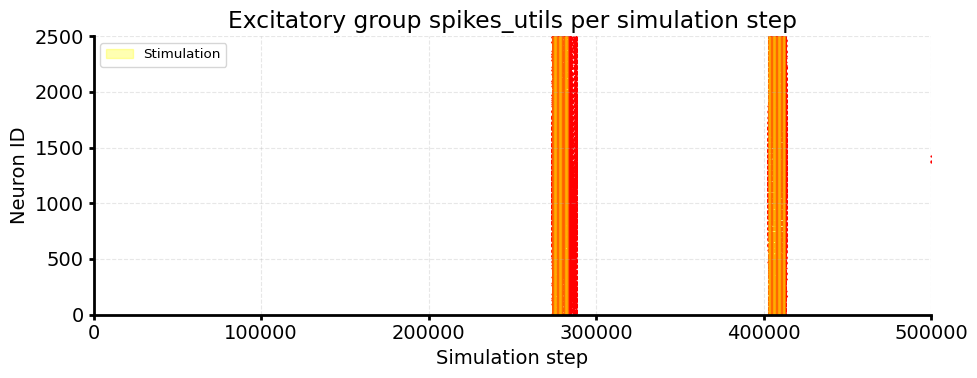

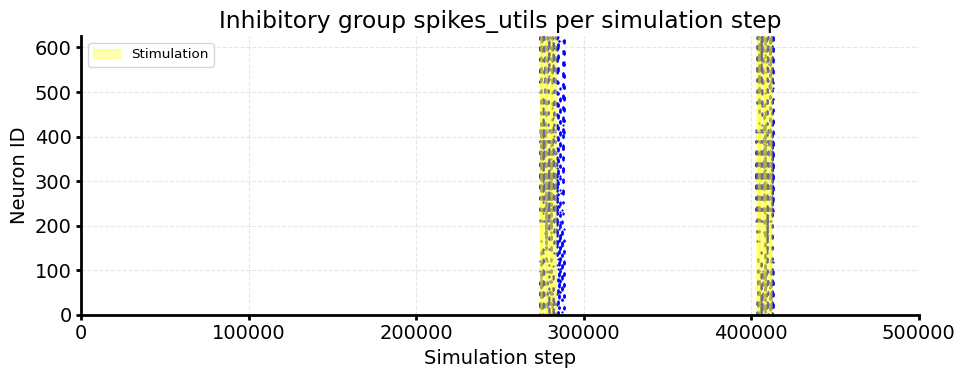

In [10]:
spikes_utils.plot_spike_recording(
    exc_spike_matrix,
    title='Excitatory group spikes_utils per simulation step',
    color='red',
    step_min=STEP_MIN,
    step_max=STEP_MAX,
)
# plt.ylim(0, 500)
# plt.xlim(270000, 300000)
for i, (stim_start, stim_end) in enumerate(zip(stimulus_start_clock_steps, stimulus_end_clock_steps)):
    plt.axvspan(
        stim_start,
        stim_end,
        color='yellow',
        alpha=0.3,
        label='Stimulation' if i == 0 else None
    )
plt.legend(loc='upper left')
plt.savefig(BURYNOUTPUTS_DIR+'/plots/group_e_spikes.png')
plt.show()

spikes_utils.plot_spike_recording(
    inh_spike_matrix,
    title='Inhibitory group spikes_utils per simulation step',
    color='blue',
    step_min=STEP_MIN,
    step_max=STEP_MAX,
)
plt.ylim(0, NUM_NEURONS_TO_PLOT/4)
for i, (stim_start, stim_end) in enumerate(zip(stimulus_start_clock_steps, stimulus_end_clock_steps)):
    plt.axvspan(
        stim_start,
        stim_end,
        color='yellow',
        alpha=0.3,
        label='Stimulation' if i == 0 else None
    )
plt.legend(loc='upper left')
plt.savefig(BURYNOUTPUTS_DIR+'/plots/group_i_spikes.png')
plt.show()


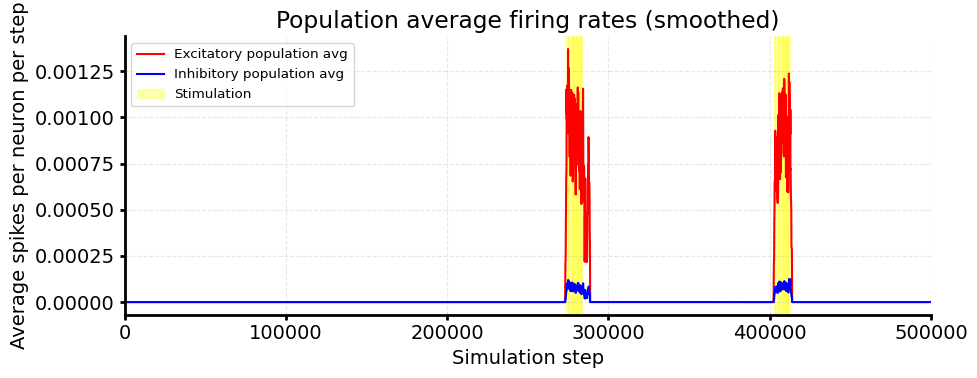

In [11]:
# Population average spiking rates for both groups
smoothing_window =1000
window = np.ones(smoothing_window) / smoothing_window
exc_population_rate = np.convolve(exc_spike_matrix.mean(axis=0), window, mode='same')
inh_population_rate = np.convolve(inh_spike_matrix.mean(axis=0), window, mode='same')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(exc_population_rate, color='red', label='Excitatory population avg')
ax.plot(inh_population_rate, color='blue', label='Inhibitory population avg')
for i, (stim_start, stim_end) in enumerate(zip(stimulus_start_clock_steps, stimulus_end_clock_steps)):
    plt.axvspan(
        stim_start,
        stim_end,
        color='yellow',
        alpha=0.3,
        label='Stimulation' if i == 0 else None
    )
ax.set_title('Population average firing rates (smoothed)')
ax.set_xlabel('Simulation step')
ax.set_ylabel('Average spikes per neuron per step')
ax.set_xlim(STEP_MIN, STEP_MAX)
ax.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
fig.tight_layout()
plt.show()

np.save(BURYNOUTPUTS_DIR+'/plots/exc_population_rate.npy', exc_population_rate)
np.save(BURYNOUTPUTS_DIR+'/plots/inh_population_rate.npy', inh_population_rate)

In [12]:
# spikes_utils.plot_smoothed_spike_rates(
#     exc_spike_matrix,
#     title='Excitatory group smoothed firing rates',
#     color_map='Reds',
#     smoothing_window=5000, # number of simulation steps to average over, e.g., 1000 steps = 100 ms at 0.1 ms timestep
#     step_min=STEP_MIN,
#     step_max=STEP_MAX,
# )
# plt.show()


# spikes_utils.plot_smoothed_spike_rates(
#     inh_spike_matrix,
#     title='Inhibitory group smoothed firing rates',
#     color_map='Blues',
#     smoothing_window=5000, # number of simulation steps to average over, e.g., 1000 steps = 100 ms at 0.1 ms timestep
#     step_min=STEP_MIN,
#     step_max=STEP_MAX,
# )
# plt.ylim(0, NUM_NEURONS_TO_PLOT/4)
# plt.show()
